<a href="https://colab.research.google.com/github/Momna-01/MomnaMunir_PythonProgramming/blob/main/Task3_CNN_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Loading CIFAR-10 Dataset ---
--- Training CNN Model ---
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3812 - loss: 1.6907 - val_accuracy: 0.4679 - val_loss: 1.4631
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4941 - loss: 1.4093 - val_accuracy: 0.5212 - val_loss: 1.3546
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5393 - loss: 1.2960 - val_accuracy: 0.5824 - val_loss: 1.1854
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5696 - loss: 1.2214 - val_accuracy: 0.6108 - val_loss: 1.1044
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5875 - loss: 1.1671 - val_accuracy: 0.5719 - val_loss: 1.2498
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6010 - loss: 1.1315 - val_accuracy: 0.6236 - val_loss: 1.0613
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6146 - loss: 1.0935 - val_accuracy: 0.6285 - val_loss: 1.0682
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7

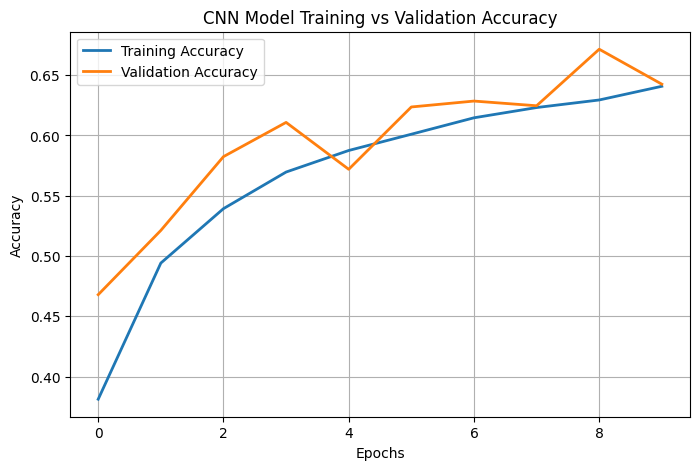

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Step 1: Ingest Vision Dataset (CIFAR-10)
print("--- Loading CIFAR-10 Dataset ---")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Step 2: Data Augmentation Techniques (Flip, Rotation, Zoom)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Step 3: Custom CNN Architecture
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Step 4: Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train Model over 10 Epochs
print("--- Training CNN Model ---")
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=64)

# Step 6: Graph Training/Validation Accuracy Curves
print("--- Plotting Accuracy Curves ---")
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('CNN Model Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()